# EDA — Exploratory Data Analysis

Comprehensive exploration of the Kaggle *Fake and Real News* dataset.  
Goal: understand the data characteristics and motivate every preprocessing decision in `02_preprocessing.ipynb`.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import mannwhitneyu
import re
import warnings

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

LABEL_NAMES = {0: "Fake", 1: "Real"}
LABEL_COLORS = {0: "#e74c3c", 1: "#2ecc71"}

/Users/aoleszkiewicz/dev/factlens/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load raw data from Kaggle

In [2]:
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

In [3]:
true_df = pd.read_csv(f"{path}/True.csv")
fake_df = pd.read_csv(f"{path}/Fake.csv")

true_df["label"] = 1
fake_df["label"] = 0

news_df = pd.concat([true_df, fake_df], ignore_index=True)
print(f"True articles: {len(true_df):,}")
print(f"Fake articles: {len(fake_df):,}")
print(f"Total: {len(news_df):,}")

True articles: 21,417
Fake articles: 23,481
Total: 44,898


## 1. Data Overview

In [4]:
print(f"Shape: {news_df.shape}")
print(f"\nColumns: {list(news_df.columns)}")
print()
news_df.info()

Shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [5]:
news_df.describe(include="all")

,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


In [6]:
pd.set_option("display.max_colwidth", 200)

print("=== Sample REAL articles ===")
display(news_df[news_df["label"] == 1].sample(3, random_state=42))

print("\n=== Sample FAKE articles ===")
display(news_df[news_df["label"] == 0].sample(3, random_state=42))

=== Sample REAL articles ===


,title,text,subject,date,label
18137,Europe rights watchdog says Turkey's emergency laws go too far,BRUSSELS (Reuters) - A leading European rights watchdog called on Turkey on Friday to ease post-coup state of emergency laws that have seen thousands arrested and restore power to regional authori...,worldnews,"October 6, 2017",1
3277,Exclusive: Trump targets illegal immigrants who were given reprieves from deportation by Obama,"(Reuters) - In September 2014, Gilberto Velasquez, a 38-year-old house painter from El Salvador, received life-changing news: The U.S. government had decided to shelve its deportation action again...",politicsNews,"June 9, 2017",1
2876,"At G20 summit, Trump pledges $639 million in aid to four countries","HAMBURG (Reuters) - U.S. President Donald Trump on Saturday promised $639 million in aid to feed people left starving because of drought and conflict in Somalia, South Sudan, Nigeria and Yemen. Tr...",politicsNews,"July 8, 2017",1



=== Sample FAKE articles ===


,title,text,subject,date,label
34891,ABOUT HILLARY’S COUGH: We Discovered The Secret To Why She Keeps Coughing [Video],,politics,"Jul 20, 2016",0
33411,BREAKING: OBAMACARE REPEAL Clears First Hurdle…Dems Get Snarky,"The Senate voted 51-48 this afternoon to proceed to the resolution, S. Con. Res. 3, which would set up a filibuster-proof process, ensuring the chamber s consideration of legislation repealing par...",politics,"Jan 4, 2017",0
40596,‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Saying She’d Back Abolition Of The Electoral College [Video],So much for the SCOTUS not being political Check out her comments on equality for women. It s like she s time traveled back to the 50 s. What is the deal with these women that think we re still in...,left-news,"Feb 7, 2017",0


## 2. Metadata Exploration (title, subject, date)

Before dropping these columns, let's explore what they contain and why they shouldn't be used as model features.

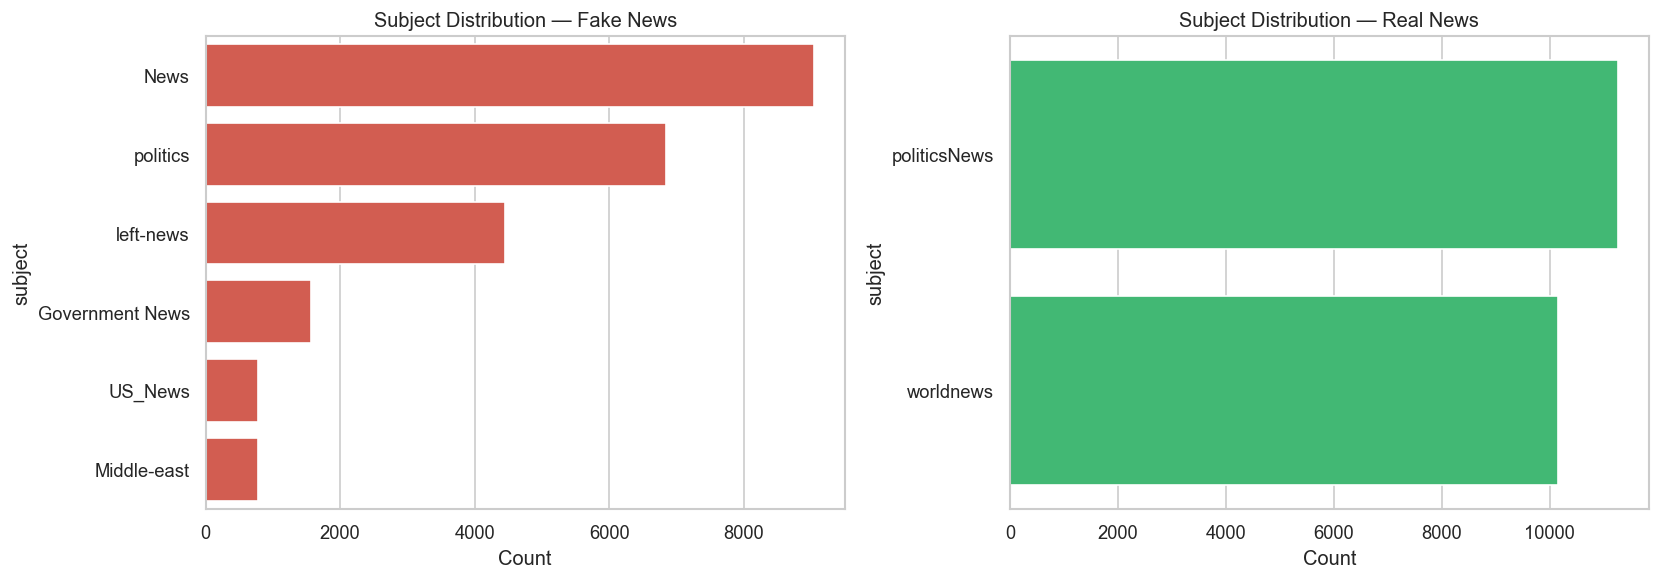

Subject counts by class:
label  subject        
0      News                9050
       politics            6841
       left-news           4459
       Government News     1570
       US_News              783
       Middle-east          778
1      politicsNews       11272
       worldnews          10145
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, name) in zip(axes, LABEL_NAMES.items()):
    subset = news_df[news_df["label"] == label]
    order = subset["subject"].value_counts().index
    sns.countplot(data=subset, y="subject", order=order, ax=ax, color=LABEL_COLORS[label])
    ax.set_title(f"Subject Distribution — {name} News")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.show()

print("Subject counts by class:")
print(news_df.groupby("label")["subject"].value_counts())

Unparseable dates: 23481
Date range: 2016-01-13 00:00:00 to 2017-12-31 00:00:00


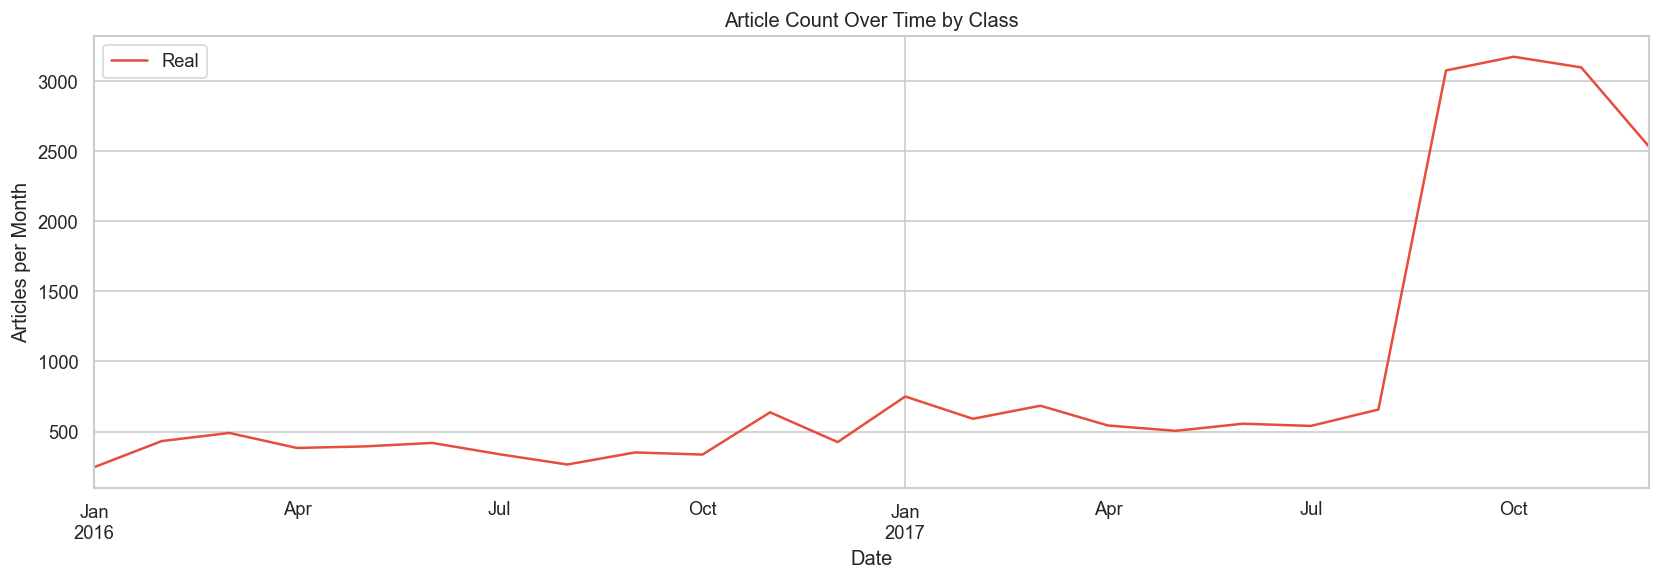

In [8]:
news_df["date_parsed"] = pd.to_datetime(news_df["date"], errors="coerce")

print(f"Unparseable dates: {news_df['date_parsed'].isna().sum()}")
print(f"Date range: {news_df['date_parsed'].min()} to {news_df['date_parsed'].max()}")

monthly = (
    news_df.dropna(subset=["date_parsed"])
    .groupby([pd.Grouper(key="date_parsed", freq="ME"), "label"])
    .size()
    .unstack(fill_value=0)
)
monthly.columns = [LABEL_NAMES[c] for c in monthly.columns]

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(ax=ax, color=[LABEL_COLORS[0], LABEL_COLORS[1]])
ax.set_title("Article Count Over Time by Class")
ax.set_xlabel("Date")
ax.set_ylabel("Articles per Month")
plt.tight_layout()
plt.show()

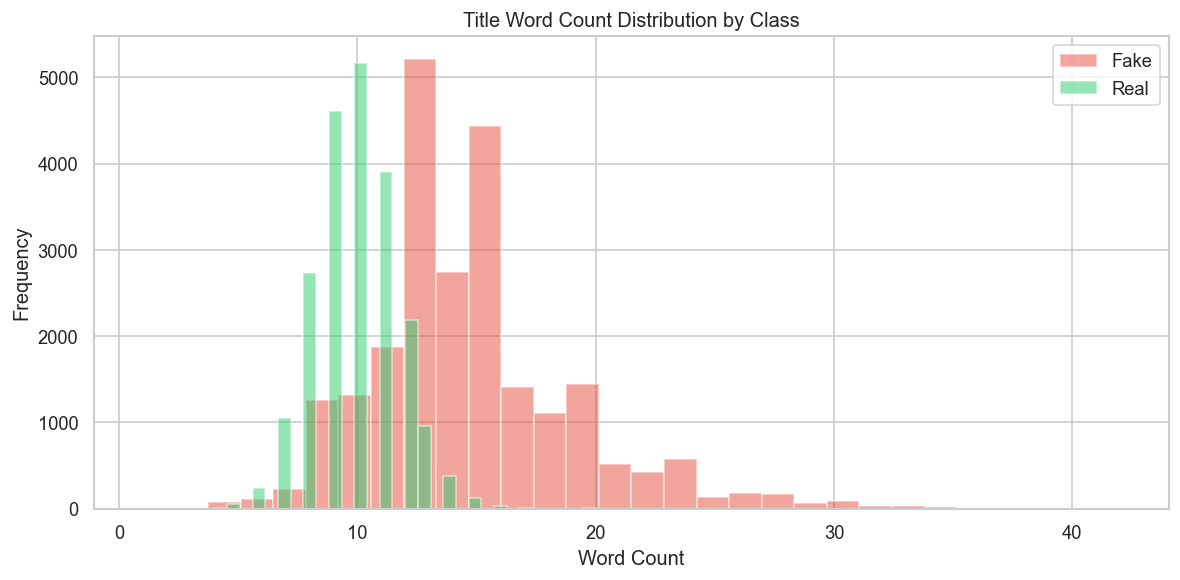

Title word count stats by class:
         count       mean       std  min   25%   50%   75%   max
label                                                           
0      23481.0  14.732805  4.335099  1.0  12.0  14.0  17.0  42.0
1      21417.0   9.954475  1.700747  4.0   9.0  10.0  11.0  20.0


In [9]:
news_df["title_word_count"] = news_df["title"].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 5))
for label, name in LABEL_NAMES.items():
    subset = news_df[news_df["label"] == label]
    ax.hist(subset["title_word_count"].dropna(), bins=30, alpha=0.5,
            label=name, color=LABEL_COLORS[label])
ax.set_title("Title Word Count Distribution by Class")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

print("Title word count stats by class:")
print(news_df.groupby("label")["title_word_count"].describe())

**Rationale for dropping metadata columns:**
- **subject** — categories are completely different between classes (e.g. `politicsNews` only in real), making it a trivially leaking feature
- **date** — temporal patterns may reflect collection methodology rather than content differences
- **title** — redundant with the article text; using both would complicate the model without clear benefit

From this point forward we work with `text` and `label` only.

In [10]:
news_df = news_df[["text", "label"]].copy()
news_df.head()

,text,label
0,"WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fis...",1
1,"WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said on Friday, after Pres...",1
2,"WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election campaign should continue without interference in 2018, despite calls from some ...",1
3,"WASHINGTON (Reuters) - Trump campaign adviser George Papadopoulos told an Australian diplomat in May 2016 that Russia had political dirt on Democratic presidential candidate Hillary Clinton, the N...",1
4,"SEATTLE/WASHINGTON (Reuters) - President Donald Trump called on the U.S. Postal Service on Friday to charge “much more” to ship packages for Amazon (AMZN.O), picking another fight with an online r...",1


## 3. Class Distribution

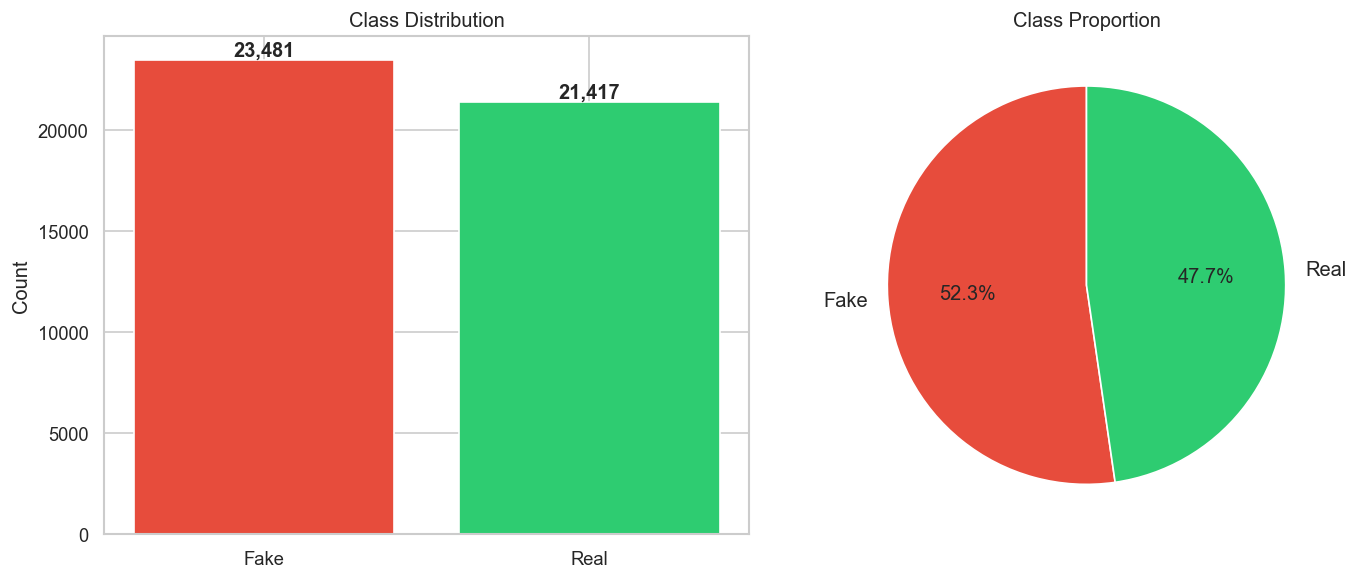

Imbalance ratio (Fake/Real): 1.096
Classes are well balanced — no resampling needed.


In [11]:
counts = news_df["label"].value_counts().sort_index()
labels = [LABEL_NAMES[i] for i in counts.index]
colors = [LABEL_COLORS[i] for i in counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars = ax1.bar(labels, counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f"{val:,}", ha="center", fontweight="bold")
ax1.set_title("Class Distribution")
ax1.set_ylabel("Count")

ax2.pie(counts.values, labels=labels, colors=colors, autopct="%1.1f%%",
        startangle=90, textprops={"fontsize": 12})
ax2.set_title("Class Proportion")

plt.tight_layout()
plt.show()

ratio = counts[0] / counts[1]
print(f"Imbalance ratio (Fake/Real): {ratio:.3f}")
print(f"Classes are {'well' if ratio < 1.5 else 'not'} balanced — no resampling needed.")

## 4. Missing and Empty Text

In [12]:
print("Null values per column:")
print(news_df.isnull().sum())

empty_mask = news_df["text"].str.strip() == ""
short_mask = news_df["text"].str.strip().str.len() < 10

print(f"\nEmpty text rows: {empty_mask.sum()}")
print(f"Near-empty text rows (< 10 chars): {short_mask.sum()}")

print(f"\nEmpty texts by class:")
print(news_df[empty_mask]["label"].map(LABEL_NAMES).value_counts())

if short_mask.sum() > 0:
    print(f"\nExamples of near-empty texts:")
    display(news_df[short_mask].head(10))

Null values per column:
text     0
label    0
dtype: int64

Empty text rows: 631
Near-empty text rows (< 10 chars): 653

Empty texts by class:
label
Fake    630
Real      1
Name: count, dtype: int64

Examples of near-empty texts:


,text,label
8970,,1
32340,,0
32458,,0
32534,Enjoy:,0
32607,,0
32642,,0
32653,,0
32658,,0
32664,,0
32666,,0


## 5. Duplicate Analysis

Exact duplicate rows: 6,251 (13.9%)
Duplicate texts (ignoring label): 6,252
  Fake: 6,026 duplicates
  Real: 225 duplicates


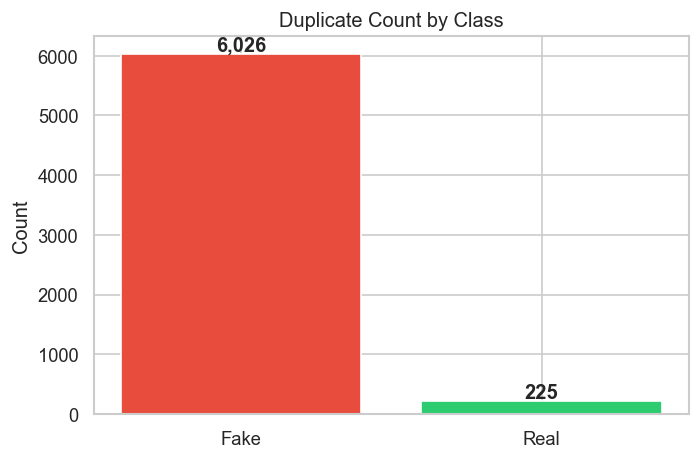

In [13]:
total_dups = news_df.duplicated().sum()
text_dups = news_df.duplicated(subset=["text"]).sum()
print(f"Exact duplicate rows: {total_dups:,} ({total_dups / len(news_df) * 100:.1f}%)")
print(f"Duplicate texts (ignoring label): {text_dups:,}")

dup_by_class = []
for label, name in LABEL_NAMES.items():
    subset = news_df[news_df["label"] == label]
    n = subset.duplicated(subset=["text"]).sum()
    dup_by_class.append({"Class": name, "Duplicates": n})
    print(f"  {name}: {n:,} duplicates")

fig, ax = plt.subplots(figsize=(6, 4))
dup_df = pd.DataFrame(dup_by_class)
bars = ax.bar(dup_df["Class"], dup_df["Duplicates"],
              color=[LABEL_COLORS[0], LABEL_COLORS[1]])
for bar, val in zip(bars, dup_df["Duplicates"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{val:,}", ha="center", fontweight="bold")
ax.set_title("Duplicate Count by Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [14]:
print("Top 10 most duplicated texts:")
top_dups = news_df["text"].value_counts().head(10)
for i, (text, count) in enumerate(top_dups.items(), 1):
    preview = text[:80] + "..." if len(text) > 80 else text
    preview = repr(preview) if text.strip() == "" else preview
    print(f"  {i}. (x{count}) {preview}")

print("\n--- Cross-class duplicates (same text, different labels = label noise) ---")
cross = news_df.groupby("text")["label"].nunique()
cross_count = (cross > 1).sum()
print(f"Texts appearing with BOTH labels: {cross_count}")
if cross_count > 0:
    conflict_texts = cross[cross > 1].index[:5]
    for t in conflict_texts:
        print(f"  '{t[:80]}...' — labels: {news_df[news_df['text'] == t]['label'].tolist()}")

Top 10 most duplicated texts:
  1. (x627) ' '
  2. (x8) (Reuters) - Highlights for U.S. President Donald Trump’s administration on Thurs...
  3. (x5) (Reuters) - Highlights for U.S. President Donald Trump’s administration on Frida...
  4. (x5) (Reuters) - Highlights of the day for U.S. President Donald Trump’s administrati...
  5. (x4) AP News  The regulars amble in before dawn and claim their usual table, the one ...
  6. (x4) '  '
  7. (x4) Because there wouldn t be any outrage over a  white kids only  field trip to a l...
  8. (x4) On September 15, Hillary  apparently  held a rally in the Old Student Recreation...
  9. (x4) Things didn t go as well as Nicholle had hoped and now, she s lashing out at the...
  10. (x4) Enjoy:

--- Cross-class duplicates (same text, different labels = label noise) ---
Texts appearing with BOTH labels: 1
  ' ...' — labels: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## 6. Text Length Analysis

In [15]:
news_df["char_count"] = news_df["text"].str.len()
news_df["word_count"] = news_df["text"].str.split().str.len()
news_df["sentence_count"] = news_df["text"].str.count(r"[.!?]+")

print("Length statistics by class:\n")
for col in ["char_count", "word_count", "sentence_count"]:
    print(f"--- {col} ---")
    print(news_df.groupby("label")[col].describe().rename(index=LABEL_NAMES))
    print()

Length statistics by class:

--- char_count ---
         count         mean          std  min     25%     50%     75%      max
label                                                                         
Fake   23481.0  2547.396235  2532.884399  1.0  1433.0  2166.0  3032.0  51794.0
Real   21417.0  2383.278517  1684.835730  1.0   914.0  2222.0  3237.0  29781.0

--- word_count ---
         count        mean         std  min    25%    50%    75%     max
label                                                                   
Fake   23481.0  423.197905  408.388890  0.0  240.0  363.0  506.0  8135.0
Real   21417.0  385.640099  274.006204  0.0  148.0  359.0  525.0  5172.0

--- sentence_count ---
         count       mean        std  min   25%   50%   75%    max
label                                                             
Fake   23481.0  22.703079  21.591472  0.0  12.0  19.0  28.0  772.0
Real   21417.0  20.801233  15.912271  0.0   8.0  18.0  29.0  337.0



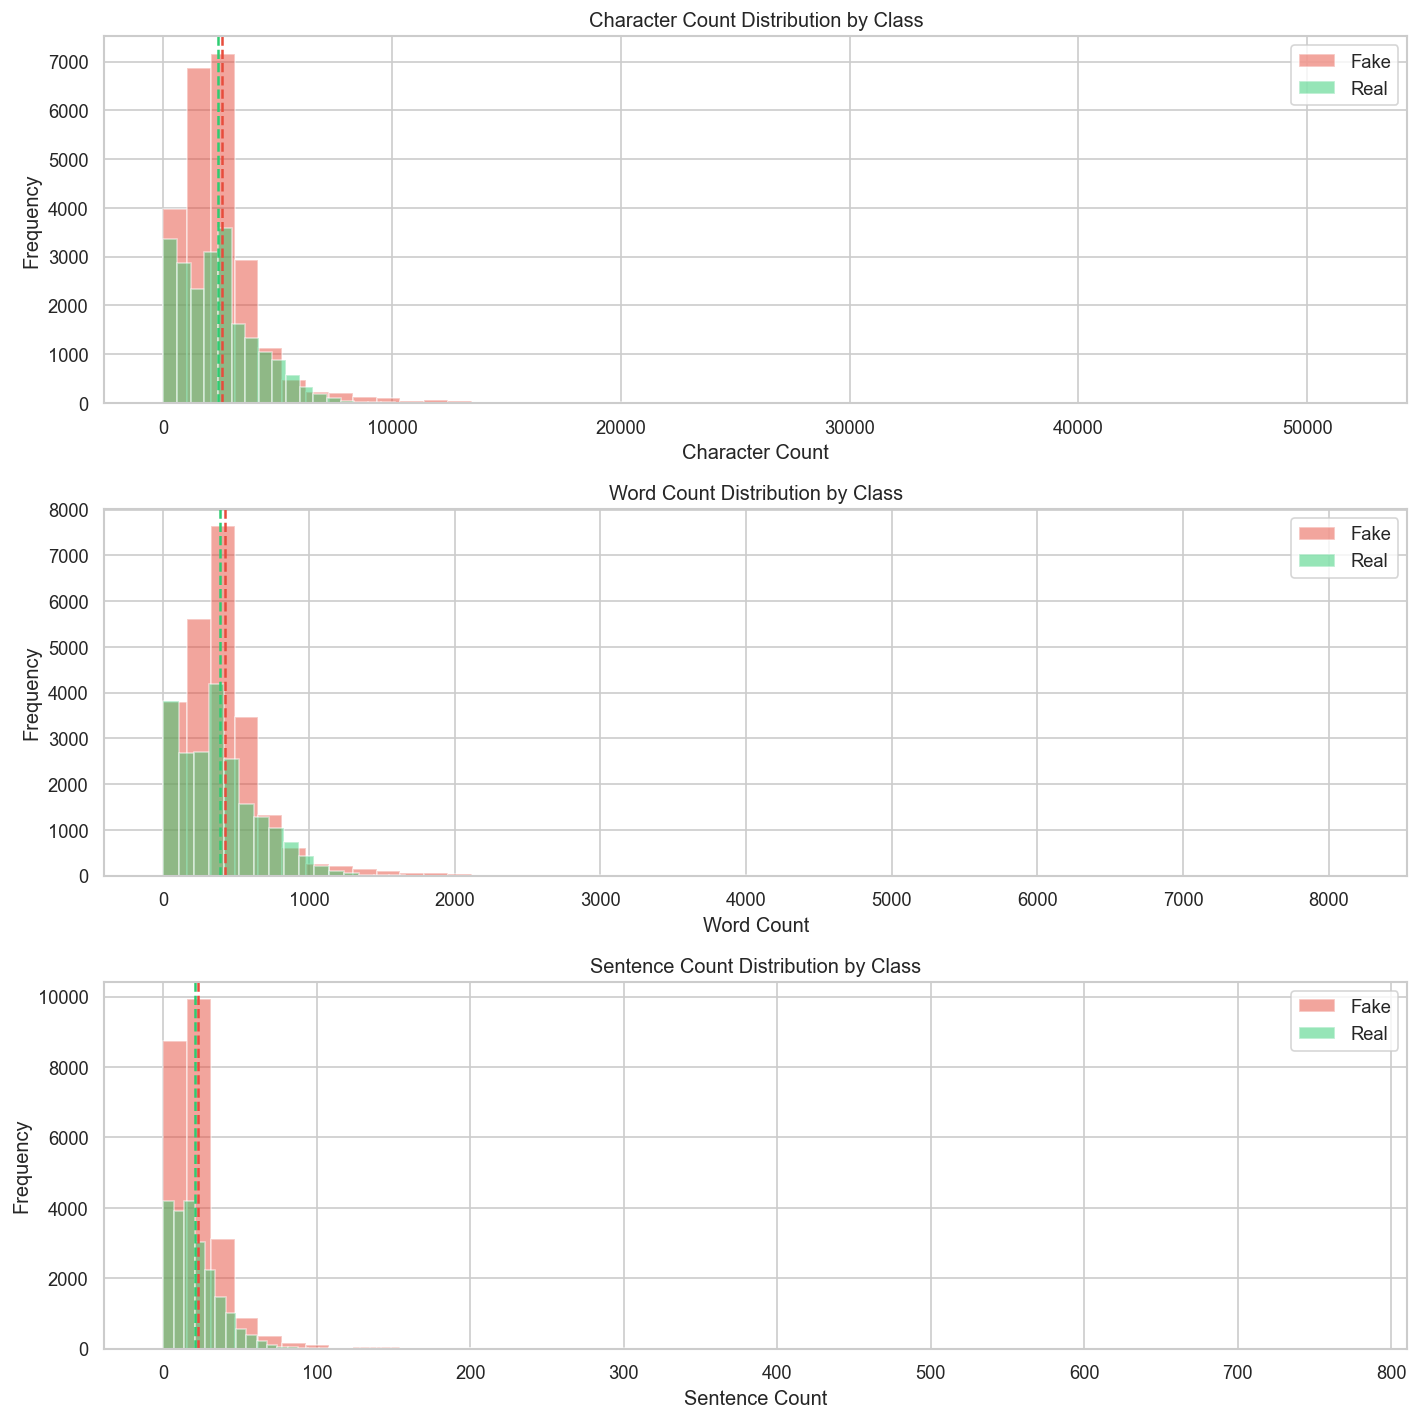

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, col, title in zip(axes, ["char_count", "word_count", "sentence_count"],
                           ["Character Count", "Word Count", "Sentence Count"]):
    for label, name in LABEL_NAMES.items():
        subset = news_df[news_df["label"] == label][col].dropna()
        ax.hist(subset, bins=50, alpha=0.5, label=name, color=LABEL_COLORS[label])
        ax.axvline(subset.mean(), color=LABEL_COLORS[label], linestyle="--", linewidth=1.5)
    ax.set_title(f"{title} Distribution by Class")
    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

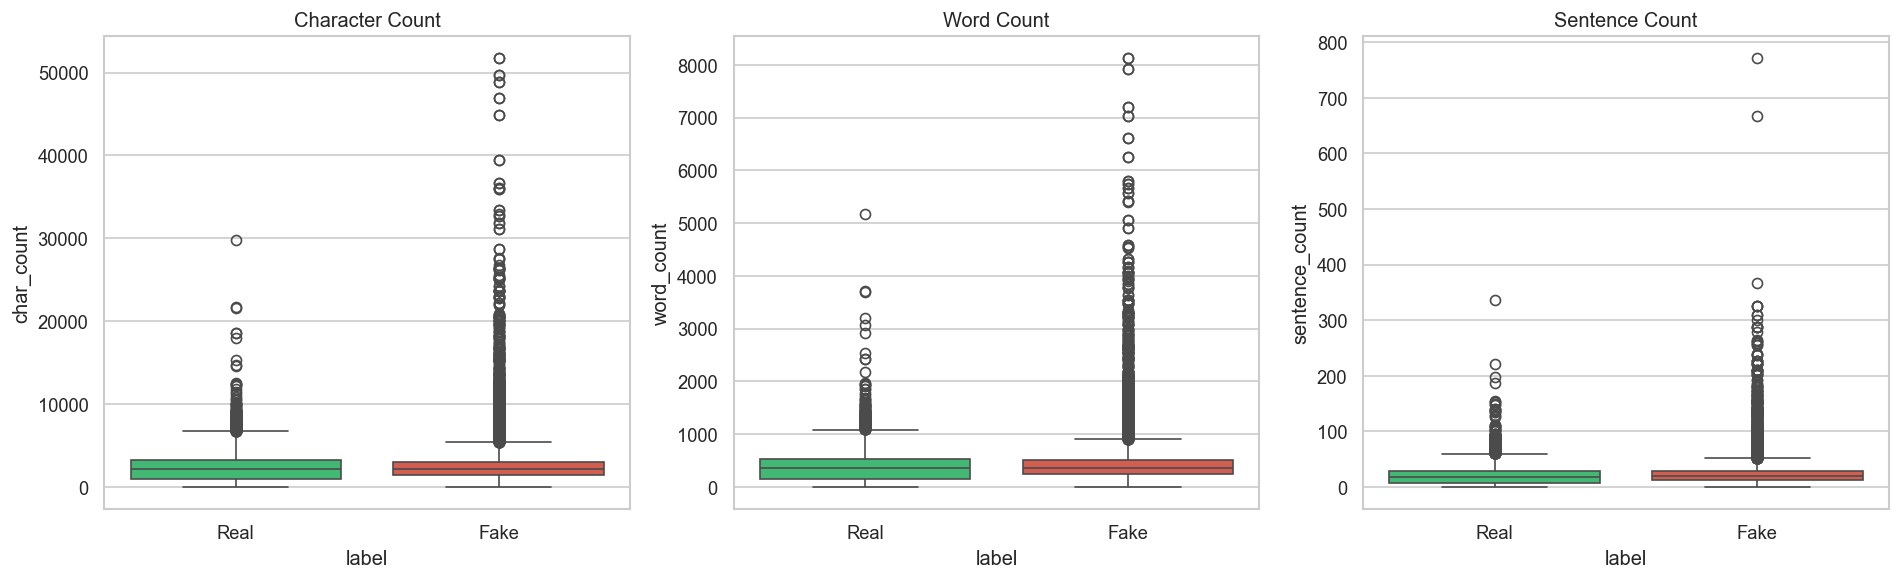

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes, ["char_count", "word_count", "sentence_count"],
                           ["Character Count", "Word Count", "Sentence Count"]):
    plot_df = news_df[["label", col]].copy()
    plot_df["label"] = plot_df["label"].map(LABEL_NAMES)
    sns.boxplot(data=plot_df, x="label", y=col, ax=ax,
                palette={"Fake": LABEL_COLORS[0], "Real": LABEL_COLORS[1]})
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [18]:
real_wc = news_df[news_df["label"] == 1]["word_count"].dropna()
fake_wc = news_df[news_df["label"] == 0]["word_count"].dropna()

stat, p_value = mannwhitneyu(real_wc, fake_wc, alternative="two-sided")
print(f"Mann-Whitney U test (word count: Real vs Fake):")
print(f"  U-statistic: {stat:,.0f}")
print(f"  p-value: {p_value:.2e}")
print(f"  {'Significant' if p_value < 0.05 else 'Not significant'} difference (alpha=0.05)")

n1, n2 = len(real_wc), len(fake_wc)
r = 1 - (2 * stat) / (n1 * n2)
print(f"  Rank-biserial correlation (effect size): {r:.4f}")

print(f"\n--- Outliers ---")
very_short = news_df[news_df["word_count"] < 5]
very_long = news_df[news_df["word_count"] > 5000]
print(f"Articles with < 5 words: {len(very_short)}")
print(f"Articles with > 5000 words: {len(very_long)}")
if len(very_short) > 0:
    print(f"\nShortest articles:")
    display(very_short.nsmallest(5, "word_count")[["text", "label", "word_count"]])

Mann-Whitney U test (word count: Real vs Fake):
  U-statistic: 241,457,620
  p-value: 3.29e-13
  Significant difference (alpha=0.05)
  Rank-biserial correlation (effect size): 0.0397

--- Outliers ---
Articles with < 5 words: 774
Articles with > 5000 words: 26

Shortest articles:


,text,label,word_count
8970,,1,0
32340,,0,0
32458,,0,0
32607,,0,0
32642,,0,0


## 7. Content Patterns — Reuters & Structural Signatures

The real articles originate from Reuters. Do structural markers create data leakage?

Articles containing '(Reuters)': 21,256 / 44,898

Breakdown by class:
label
Real    21247
Fake        9
Name: count, dtype: int64


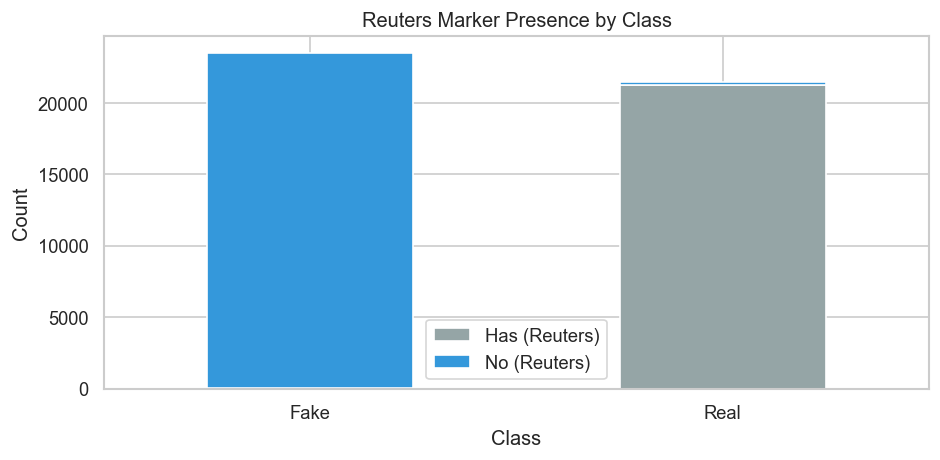


99.2% of real articles contain '(Reuters)' — this is a near-perfect class separator!
>> CRITICAL: Must remove '(Reuters)' to prevent trivial data leakage.


In [19]:
reuters_mask = news_df["text"].str.contains(r"\(Reuters\)", na=False)

print(f"Articles containing '(Reuters)': {reuters_mask.sum():,} / {len(news_df):,}")
print(f"\nBreakdown by class:")
reuters_by_class = news_df[reuters_mask]["label"].value_counts().rename(index=LABEL_NAMES)
print(reuters_by_class)

fig, ax = plt.subplots(figsize=(8, 4))
cross_tab = pd.crosstab(
    news_df["label"].map(LABEL_NAMES),
    reuters_mask.map({True: "Has (Reuters)", False: "No (Reuters)"})
)
cross_tab.plot(kind="bar", stacked=True, ax=ax,
               color=["#95a5a6", "#3498db"])
ax.set_title("Reuters Marker Presence by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pct = reuters_by_class.get("Real", 0) / counts[1] * 100
print(f"\n{pct:.1f}% of real articles contain '(Reuters)' — this is a near-perfect class separator!")
print(">> CRITICAL: Must remove '(Reuters)' to prevent trivial data leakage.")

Articles with CITY (Reuters) dateline: 17,808

Top 15 dateline cities:
text
WASHINGTON        6392
LONDON             705
NEW YORK           696
MOSCOW             623
BERLIN             500
BEIJING            433
BRUSSELS           346
BEIRUT             346
PARIS              301
ANKARA             247
MEXICO CITY        226
TOKYO              207
SEOUL              203
GENEVA             197
UNITED NATIONS     184
Name: count, dtype: int64


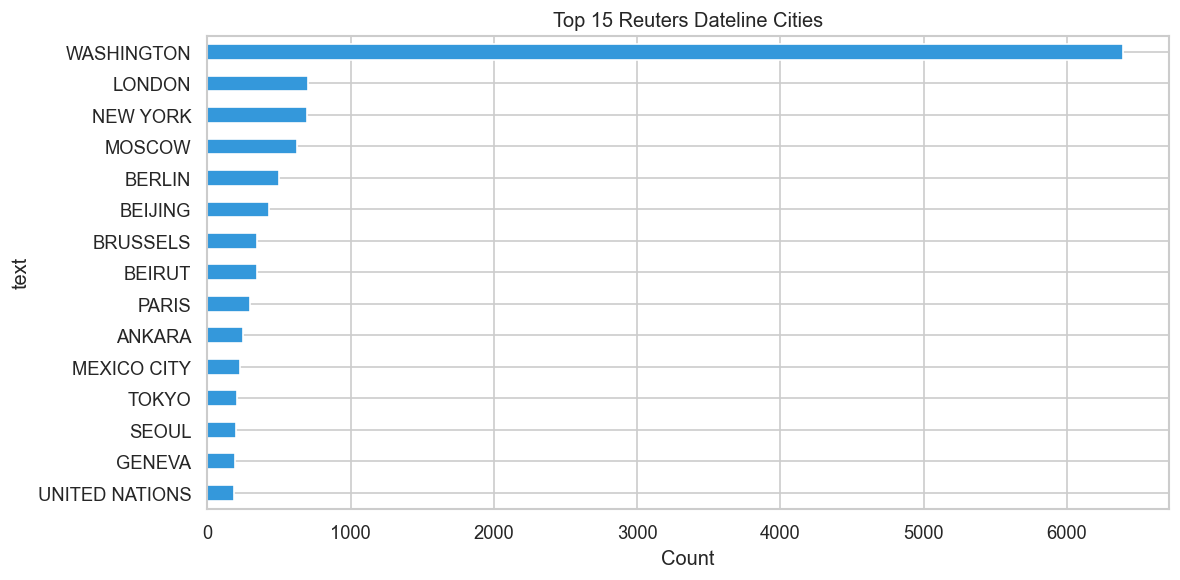

In [20]:
city_pattern = r"^([A-Z][A-Z /]+)\(Reuters\)"
cities = news_df["text"].str.extract(city_pattern, expand=False).dropna().str.strip()

print(f"Articles with CITY (Reuters) dateline: {len(cities):,}")
print(f"\nTop 15 dateline cities:")
top_cities = cities.value_counts().head(15)
print(top_cities)

fig, ax = plt.subplots(figsize=(10, 5))
top_cities.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Top 15 Reuters Dateline Cities")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
print("Common text prefixes (first 50 chars) per class:\n")
for label, name in LABEL_NAMES.items():
    subset = news_df[news_df["label"] == label]["text"]
    prefixes = subset.str[:50].value_counts().head(10)
    print(f"--- {name} News ---")
    for prefix, cnt in prefixes.items():
        print(f"  (x{cnt}) {prefix}")
    print()

Common text prefixes (first 50 chars) per class:

--- Fake News ---
  (x626)  
  (x203) Tune in to the Alternate Current Radio Network (AC
  (x12) 21st Century Wire says Our weekly documentary film
  (x12) Join Patrick every Wednesday at Independent Talk 1
  (x10)  In response to the establishment media s contrive
  (x8)  Join Patrick every Wednesday at Independent Talk 
  (x6) // <![CDATA[ (function(d, s, id) { var js, fjs = d
  (x6) https://fedup.wpengine.com/wp-content/uploads/2015
  (x5) Obama has filled his cabinet with radical  yes  me
  (x4) In fly-over country, and pretty much anywhere in b

--- Real News ---
  (x540) WASHINGTON (Reuters) - U.S. President Donald Trump
  (x91) The following statements were posted to the verifi
  (x87) WASHINGTON (Reuters) - U.S. President Barack Obama
  (x76) WASHINGTON (Reuters) - The U.S. House of Represent
  (x76) WASHINGTON (Reuters) - U.S. Secretary of State Rex
  (x75) WASHINGTON (Reuters) - President-elect Donald Trum
  (x74) WASHINGTON (

In [22]:
url_mask = news_df["text"].str.contains(r"https?://", na=False)
allcaps_count = news_df["text"].str.count(r"\b[A-Z]{3,}\b")

patterns = pd.DataFrame({
    "label": news_df["label"].map(LABEL_NAMES),
    "has_url": url_mask,
    "allcaps_words": allcaps_count,
    "exclamation_marks": news_df["text"].str.count("!"),
    "question_marks": news_df["text"].str.count(r"\?"),
})

print("Structural patterns by class:\n")
print(patterns.groupby("label").agg({
    "has_url": "sum",
    "allcaps_words": "mean",
    "exclamation_marks": "mean",
    "question_marks": "mean",
}).round(2).rename(columns={
    "has_url": "Articles with URLs",
    "allcaps_words": "Avg ALL-CAPS words",
    "exclamation_marks": "Avg ! marks",
    "question_marks": "Avg ? marks",
}))

Structural patterns by class:

       Articles with URLs  Avg ALL-CAPS words  Avg ! marks  Avg ? marks
label                                                                  
Fake                 3299                4.89         0.72         1.21
Real                    0                3.07         0.06         0.10


## 8. Word Frequency Analysis

In [23]:
stop_words = set(stopwords.words("english"))

def get_word_freq(texts, remove_stopwords=True):
    words = []
    for text in texts.dropna():
        tokens = text.lower().split()
        if remove_stopwords:
            tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
        words.extend(tokens)
    return Counter(words)

real_freq = get_word_freq(news_df[news_df["label"] == 1]["text"])
fake_freq = get_word_freq(news_df[news_df["label"] == 0]["text"])

print(f"Total tokens (excl. stopwords) — Real: {sum(real_freq.values()):,}, Fake: {sum(fake_freq.values()):,}")

Total tokens (excl. stopwords) — Real: 3,913,444, Fake: 4,385,585


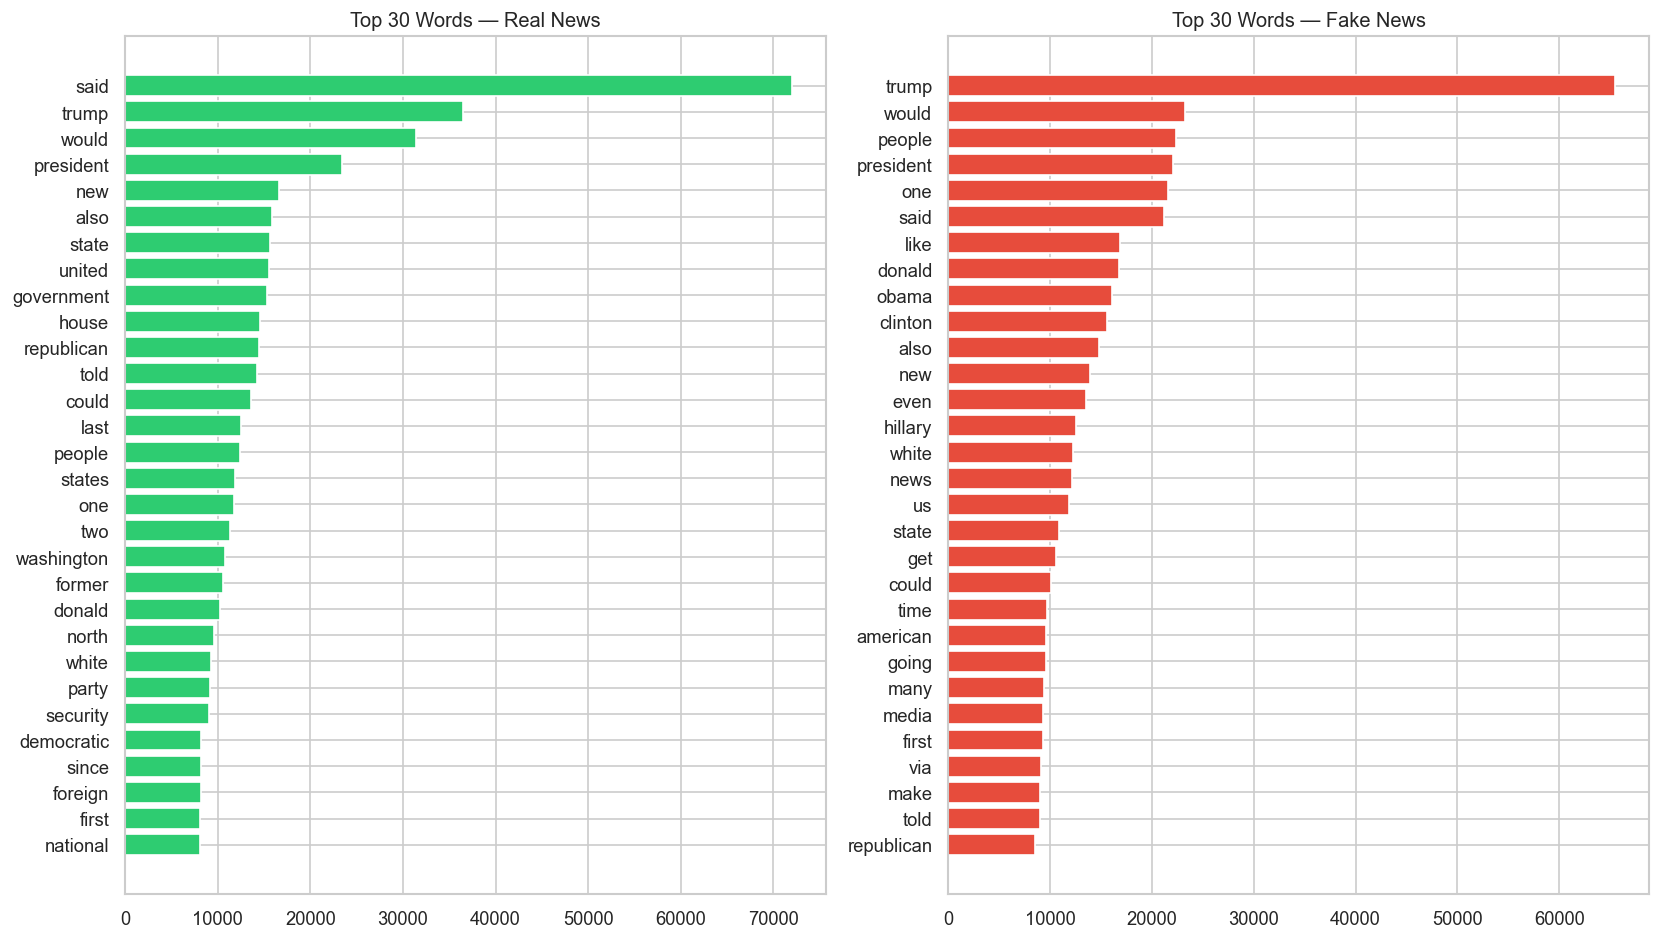

In [24]:
n = 30
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

real_top = real_freq.most_common(n)
fake_top = fake_freq.most_common(n)

ax1.barh([w for w, _ in real_top][::-1], [c for _, c in real_top][::-1],
         color=LABEL_COLORS[1])
ax1.set_title(f"Top {n} Words — Real News")

ax2.barh([w for w, _ in fake_top][::-1], [c for _, c in fake_top][::-1],
         color=LABEL_COLORS[0])
ax2.set_title(f"Top {n} Words — Fake News")

plt.tight_layout()
plt.show()

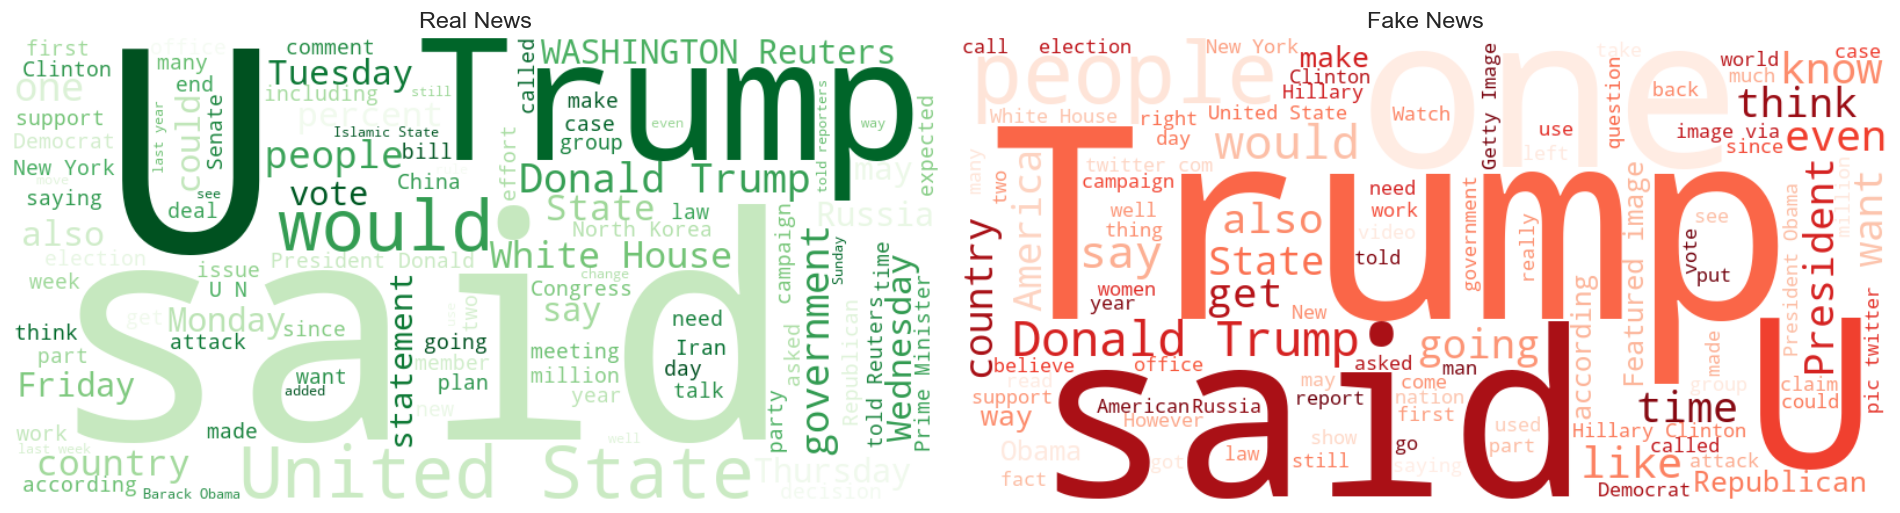

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

real_text = " ".join(news_df[news_df["label"] == 1]["text"].dropna())
fake_text = " ".join(news_df[news_df["label"] == 0]["text"].dropna())

wc_real = WordCloud(width=800, height=400, background_color="white",
                    colormap="Greens", stopwords=stop_words, max_words=100)
wc_fake = WordCloud(width=800, height=400, background_color="white",
                    colormap="Reds", stopwords=stop_words, max_words=100)

ax1.imshow(wc_real.generate(real_text), interpolation="bilinear")
ax1.set_title("Real News", fontsize=14)
ax1.axis("off")

ax2.imshow(wc_fake.generate(fake_text), interpolation="bilinear")
ax2.set_title("Fake News", fontsize=14)
ax2.axis("off")

plt.tight_layout()
plt.show()

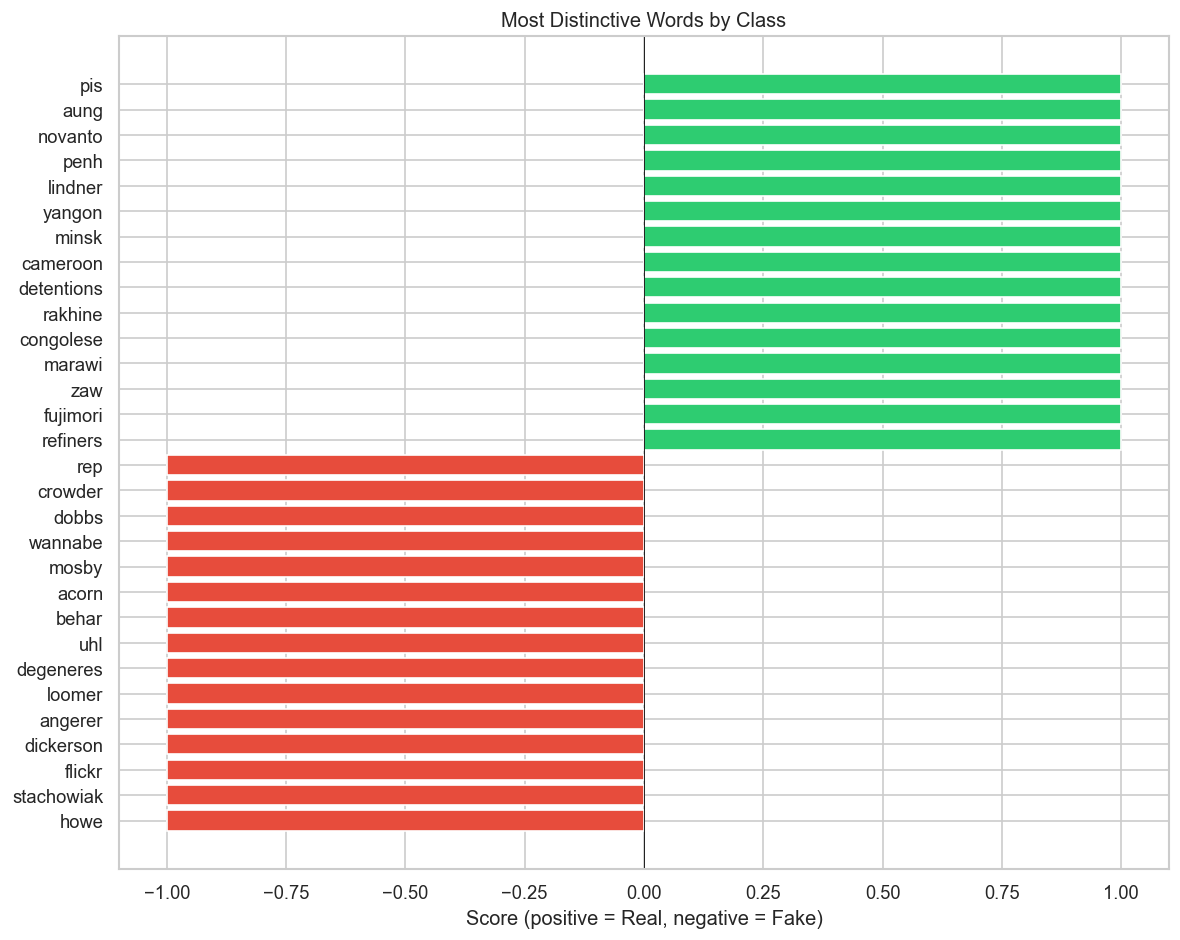

In [26]:
all_words = set(real_freq.keys()) | set(fake_freq.keys())
total_real = sum(real_freq.values())
total_fake = sum(fake_freq.values())

distinctiveness = []
for word in all_words:
    rf = real_freq.get(word, 0) / total_real
    ff = fake_freq.get(word, 0) / total_fake
    if rf + ff > 0:
        score = (rf - ff) / (rf + ff)
        total = real_freq.get(word, 0) + fake_freq.get(word, 0)
        if total >= 50:
            distinctiveness.append((word, score, total))

dist_df = pd.DataFrame(distinctiveness, columns=["word", "score", "total"])
most_real = dist_df.nlargest(15, "score")
most_fake = dist_df.nsmallest(15, "score")
plot_df = pd.concat([most_real, most_fake]).sort_values("score")

fig, ax = plt.subplots(figsize=(10, 8))
colors = [LABEL_COLORS[1] if s > 0 else LABEL_COLORS[0] for s in plot_df["score"]]
ax.barh(plot_df["word"], plot_df["score"], color=colors)
ax.set_title("Most Distinctive Words by Class")
ax.set_xlabel("Score (positive = Real, negative = Fake)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 9. Vocabulary Analysis

Vocabulary sizes:
  Real: 53,406
  Fake: 62,140
  Overlap: 33,168
  Real-only: 20,238
  Fake-only: 28,972
  Total unique words: 82,378


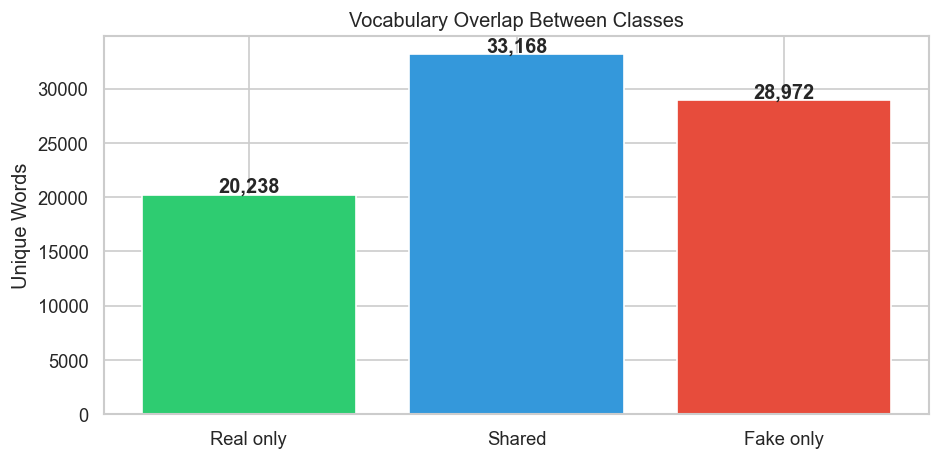

In [27]:
real_vocab = set(real_freq.keys())
fake_vocab = set(fake_freq.keys())
overlap = real_vocab & fake_vocab
real_only = real_vocab - fake_vocab
fake_only = fake_vocab - real_vocab

print(f"Vocabulary sizes:")
print(f"  Real: {len(real_vocab):,}")
print(f"  Fake: {len(fake_vocab):,}")
print(f"  Overlap: {len(overlap):,}")
print(f"  Real-only: {len(real_only):,}")
print(f"  Fake-only: {len(fake_only):,}")
print(f"  Total unique words: {len(real_vocab | fake_vocab):,}")

fig, ax = plt.subplots(figsize=(8, 4))
categories = ["Real only", "Shared", "Fake only"]
values = [len(real_only), len(overlap), len(fake_only)]
colors_bar = [LABEL_COLORS[1], "#3498db", LABEL_COLORS[0]]
bars = ax.bar(categories, values, color=colors_bar)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{val:,}", ha="center", fontweight="bold")
ax.set_title("Vocabulary Overlap Between Classes")
ax.set_ylabel("Unique Words")
plt.tight_layout()
plt.show()

In [28]:
real_hapax = sum(1 for w, c in real_freq.items() if c == 1)
fake_hapax = sum(1 for w, c in fake_freq.items() if c == 1)

real_ttr = len(real_vocab) / sum(real_freq.values())
fake_ttr = len(fake_vocab) / sum(fake_freq.values())

metrics = pd.DataFrame({
    "Metric": ["Hapax legomena (words appearing once)", "Hapax % of vocabulary",
               "Type-Token Ratio (lexical diversity)"],
    "Real": [f"{real_hapax:,}", f"{real_hapax / len(real_vocab) * 100:.1f}%", f"{real_ttr:.4f}"],
    "Fake": [f"{fake_hapax:,}", f"{fake_hapax / len(fake_vocab) * 100:.1f}%", f"{fake_ttr:.4f}"],
})
print("Vocabulary diversity metrics:")
display(metrics.set_index("Metric"))

Vocabulary diversity metrics:


,Real,Fake
Metric,,
Hapax legomena (words appearing once),"15,944","13,874"
Hapax % of vocabulary,29.9%,22.3%
Type-Token Ratio (lexical diversity),0.0136,0.0142


## 10. Summary & Preprocessing Recommendations

### Key Findings

| # | Finding | Preprocessing Action | Impact |
|---|---------|---------------------|--------|
| 1 | 6,251 duplicate rows (13.9%) | `drop_duplicates()` | 44,898 → 38,647 rows |
| 2 | Empty/near-empty text rows | Remove or flag | Cleaner training data |
| 3 | 21,030 articles with `(Reuters)` marker — almost all in real class | `str.replace(r"\(Reuters\)", "")` | **Prevent data leakage** |
| 4 | City dateline prefixes (e.g. "WASHINGTON - ") only in real class | Consider removal | Further leakage prevention |
| 5 | Excessive/inconsistent whitespace | `re.sub(r"\s+", " ", text)` | Normalize spacing |
| 6 | Single-character word artifacts | `re.sub(r"\s+[a-zA-Z]\s+", " ", text)` | Cleaner tokenization |
| 7 | Mixed case throughout | `.lower()` | Normalize vocabulary |

### Open Questions for Thesis Discussion

- **Dateline removal**: Should `CITY (Reuters) -` prefix also be stripped? It's another leaking signal.
- **URL removal**: Some articles contain URLs — strip them or keep as features?
- **Single-char removal aggressiveness**: The regex also removes legitimate words like "I" and "a" — acceptable trade-off?
- **Minimum length threshold**: Should articles below a certain word count be dropped entirely?

These findings directly inform the preprocessing pipeline implemented in `02_preprocessing.ipynb`.